In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Load Dataset

In [2]:
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')

In [3]:
train_df.shape

(471, 785)

In [4]:
test_df.shape

(468, 785)

In [5]:
train_df.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,471.000000,...,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000
mean,4.560510,0.029724,0.029724,0.048832,0.106157,0.167728,0.333333,0.615711,1.876858,4.887473,...,32.523404,21.702128,14.331915,14.272340,20.731915,18.421277,10.651064,3.919149,0.968085,0.093617
std,2.820904,0.645086,0.482863,0.505032,0.998608,1.424519,2.679579,6.074965,11.526921,20.032157,...,54.726286,45.035743,36.548832,37.052407,48.454410,46.048843,32.650073,18.935584,8.238518,1.490468
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,51.750000,13.750000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,9.000000,14.000000,10.000000,10.000000,20.000000,26.000000,50.000000,121.000000,175.000000,198.000000,...,227.000000,216.000000,219.000000,222.000000,233.000000,237.000000,234.000000,168.000000,112.000000,30.000000


In [6]:
train_df.label.unique()

array([2, 9, 6, 0, 3, 4, 5, 8, 7, 1], dtype=int64)

In [7]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [8]:
x_train = train_df.iloc[:,1:].to_numpy()
x_train = x_train.reshape([-1,28,28,1])
x_train = x_train / 255

In [9]:
y_train = train_df.iloc[:,0].to_numpy()

In [10]:
x_test = test_df.iloc[:,1:].to_numpy()
x_test = x_test.reshape([-1,28,28,1])
x_test = x_test / 255

In [11]:
y_test = test_df.iloc[:,0].to_numpy()

### Visualization

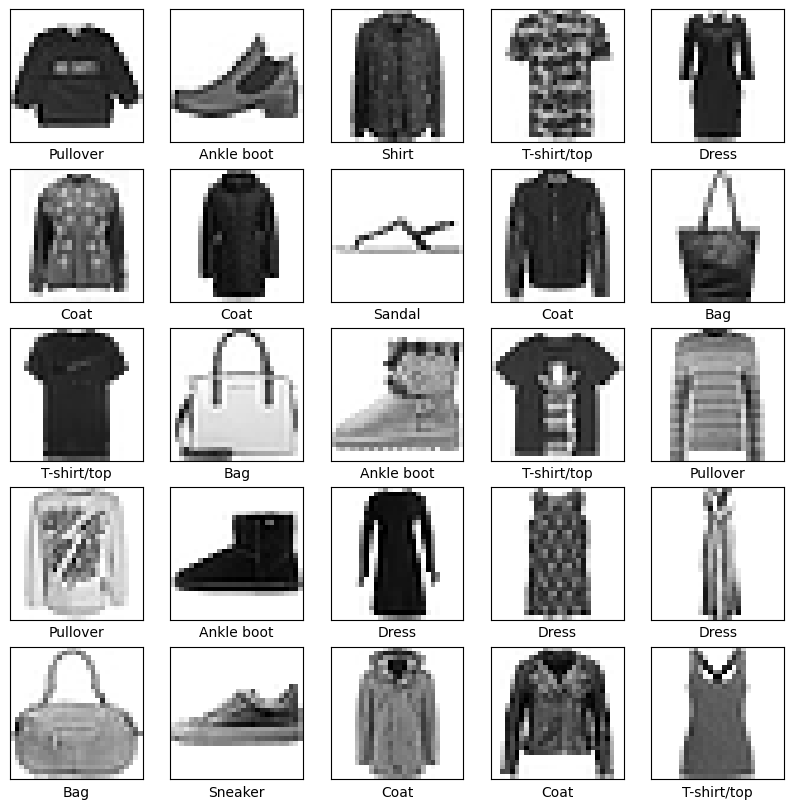

In [12]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

### Model Building

In [13]:
from keras.models import Sequential
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,Dropout

In [14]:
model = Sequential()

model.add(Conv2D(filters=64,kernel_size=(3,3),input_shape=(28,28,1),
                 activation='relu'))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(rate=0.3))
model.add(Flatten())
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=10, activation='sigmoid'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',
              metrics=['accuracy'])
model.summary()

C:\Users\chait\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 10816)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │         346,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 347,114 (1.32 MB)

 Trainable params: 347,114 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.fit(x_train,y_train,epochs=50,batch_size=1200,validation_split=0.05)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1230 - loss: 2.3002 - val_accuracy: 0.2500 - val_loss: 2.1312
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.2327 - loss: 2.1557 - val_accuracy: 0.3333 - val_loss: 1.9829
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.2886 - loss: 2.0074 - val_accuracy: 0.4167 - val_loss: 1.8413
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.3960 - loss: 1.8379 - val_accuracy: 0.4583 - val_loss: 1.7429
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.5190 - loss: 1.6895 - val_accuracy: 0.4583 - val_loss: 1.5975
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.5324 - loss: 1.5544 - val_accuracy: 0.4583 - val_loss: 1.4511
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.5280 - loss: 1.4265 - val_accuracy: 0.5000 - val_loss: 1.3286
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.5638 - loss: 1.3108 - val_accuracy: 0.6250 - val_loss: 1.

### Evaluation

In [16]:
evaluation = model.evaluate(x_test,y_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7927 - loss: 0.6591


In [17]:
print(f"Accuracy: {evaluation[1]}")

Accuracy: 0.7927350401878357


In [18]:
y_probas = model.predict(x_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [19]:
y_pred = y_probas.argmax(axis=-1)

In [20]:
y_pred

array([0, 1, 2, 6, 4, 6, 8, 6, 5, 0, 3, 4, 6, 4, 8, 5, 6, 3, 6, 4, 4, 4,
       2, 1, 5, 9, 8, 4, 4, 1, 9, 7, 9, 8, 1, 3, 9, 2, 3, 8, 2, 6, 4, 6,
       6, 0, 3, 3, 2, 3, 2, 4, 9, 3, 0, 9, 9, 4, 6, 3, 4, 5, 4, 6, 1, 1,
       0, 9, 5, 2, 7, 3, 4, 2, 5, 7, 1, 6, 1, 3, 9, 4, 1, 6, 4, 8, 9, 4,
       1, 6, 3, 4, 4, 6, 3, 3, 4, 7, 7, 3, 9, 3, 9, 6, 2, 4, 3, 2, 2, 7,
       5, 5, 3, 4, 7, 5, 0, 6, 7, 1, 0, 5, 4, 4, 7, 0, 5, 5, 0, 3, 1, 7,
       9, 4, 9, 6, 4, 6, 3, 4, 3, 3, 3, 2, 2, 6, 3, 0, 1, 3, 4, 3, 3, 1,
       9, 3, 3, 3, 9, 5, 4, 7, 7, 3, 6, 4, 0, 6, 7, 2, 6, 8, 9, 0, 6, 4,
       6, 5, 7, 9, 9, 1, 3, 9, 1, 7, 5, 4, 0, 7, 4, 9, 1, 6, 6, 0, 4, 4,
       6, 9, 0, 4, 6, 5, 5, 8, 0, 6, 1, 9, 6, 4, 7, 1, 9, 5, 9, 6, 2, 8,
       5, 9, 9, 3, 2, 4, 5, 9, 8, 1, 9, 7, 6, 2, 9, 7, 4, 0, 9, 2, 1, 5,
       7, 7, 0, 2, 4, 5, 3, 3, 8, 1, 6, 4, 4, 8, 4, 9, 2, 3, 3, 6, 4, 4,
       4, 9, 3, 9, 2, 8, 6, 8, 8, 6, 7, 2, 5, 5, 9, 7, 8, 2, 4, 8, 3, 8,
       3, 1, 2, 2, 4, 1, 8, 1, 3, 3, 3, 1, 7, 0, 7,

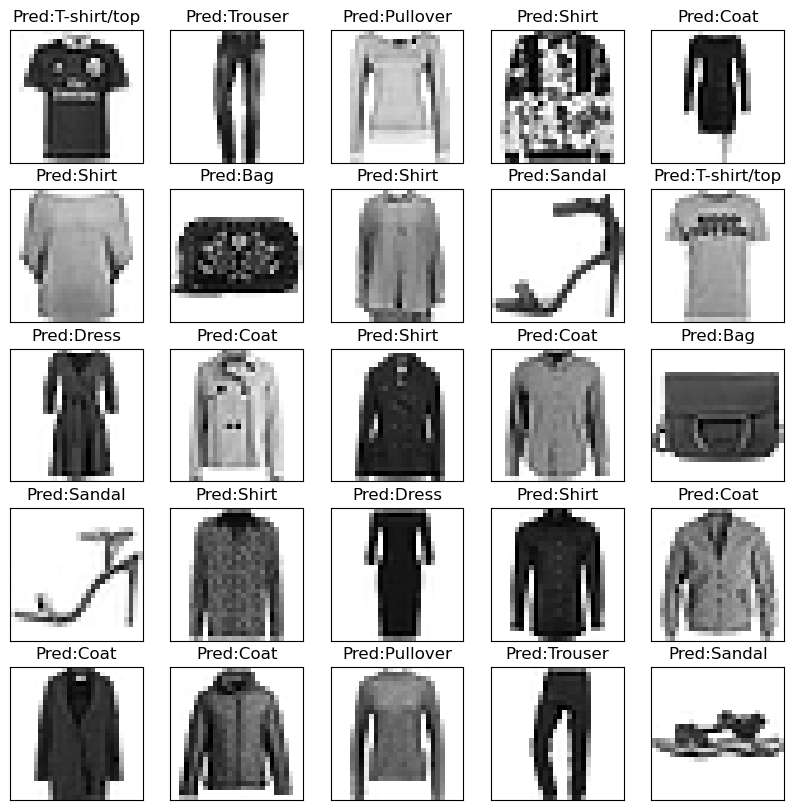

In [21]:
plt.figure(figsize=(10,10),)
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
#     plt.xlabel(f"True Class:{y_test[i]}")
    plt.title(f"Pred:{class_names[y_pred[i]]}")
plt.show()

In [22]:
from sklearn.metrics import classification_report

In [23]:
num_classes = 10
class_names = ["class {}".format(i) for i in range(num_classes)]
cr = classification_report(y_test, y_pred, target_names=class_names)
print(cr)

              precision    recall  f1-score   support

     class 0       0.85      0.67      0.75        51
     class 1       1.00      0.95      0.97        37
     class 2       0.80      0.52      0.63        61
     class 3       0.71      0.98      0.82        43
     class 4       0.69      0.81      0.75        54
     class 5       0.95      0.86      0.90        49
     class 6       0.46      0.60      0.53        43
     class 7       0.91      0.85      0.88        47
     class 8       0.91      0.82      0.86        39
     class 9       0.86      1.00      0.93        44

    accuracy                           0.79       468
   macro avg       0.82      0.81      0.80       468
weighted avg       0.81      0.79      0.79       468

